# CLED Model

## Installations and links

In [22]:
# #Tested on python 3.11.4
# !pip3 install openpyxl
# !pip3 install nltk
# !pip3 install pandas
# !pip3 install "pandas[excel]"
# !pip3 install numpy
# !pip3 install seaborn
# !pip3 install -U scikit-learn
# !pip3 install -U matplotlib
# !pip3 install xgboost
# # upenn https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html
# # universal tag https://universaldependencies.org/u/pos/
# # NER https://www.nltk.org/book/ch07.html

In [24]:
## Imports

import os
import glob
import math
import ast
import string
import re
from itertools import combinations
import time

import numpy as np
import pandas as pd

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag, ne_chunk
from nltk.stem import (
    PorterStemmer,
    LancasterStemmer,
    WordNetLemmatizer,
    SnowballStemmer,
)
from nltk.corpus import stopwords, wordnet, words

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    recall_score,
    auc,
)
# import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

# External libraries
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from joblib import dump, load



nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('universal_tagset')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download()


[nltk_data] Downloading package punkt to /Users/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/javier/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/javier/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package words to /Users/javier/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/javier/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/javier/nltk_data...
[nltk_data]   Package maxent_ne_chunker is alre

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

## Preprocess functions

In [25]:

def read_file_create_dataframe(file_path, prediction_error):
    with open(file_path, 'r') as file:
        text = file.readlines()

    data = {'text': text, 'error': prediction_error}
    df = pd.DataFrame(data)
    return df

def extract_one_per_n(df, n):
    one_per_n = df[::n]

    df = df.drop(one_per_n.index)
    df = df.reset_index(drop=True)
    one_per_n = one_per_n.reset_index(drop=True)
    return [df, one_per_n]

#df (len 100), 50, 2 -> 0,1,52,53
def subsample_error(df, group_size, n_elements_per_group):    
    final_result = pd.DataFrame()
    iteration = 0
    for i in range(0, len(df), group_size):
        group = df.iloc[i:i + group_size]  # Get a group of group_size rows
        start_point = n_elements_per_group*iteration
        n_elements = group.iloc[start_point:start_point + n_elements_per_group]
        final_result = pd.concat([final_result, n_elements])  # Concatenate with the final result DataFrame
        iteration += 1
    return final_result

def save_excel_chunks(df, file_route, chunk_size):
    df_chunks = [df[i:i + chunk_size] for i in range(0, len(df), chunk_size)]
    for i, chunk in enumerate(df_chunks):
        chunk.to_excel(f'{file_route}_{i + 1}.xlsx', index=False)


def pos_tagging(text):
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens, tagset='universal')
    return pos_tags


def getDigits():
    return "0123456789"

def getVowels():
    return "aeiouAEIOU"

def getConsonants():
    vowels = getVowels()
    characters = string.ascii_letters
    consonants = ''.join(character for character in characters if character not in vowels)
    return consonants

def getAllAscii():
    return string.ascii_lowercase + string.punctuation

def getBlank():
    return ' '

def get_POS_universal_tags():
    return ["VERB", "NOUN", "PRON", "ADJ", "ADV", "ADP", "CONJ", "DET", "NUM", "PRT", "X", "."]


def count_words(text):
    len_words = len(text.split())
    if len_words == 0:
        len_words = 1
    return len_words

def get_words_density(text):
    words = count_words(text)
    return words/len(text)


# finds sequences of min_length or more in a word made of pattern_characters in the text
# example text -> aiaio fafa aiaio , patterhn -> vowels, min_length -> 4: return 2 (aiaio aiaio)
def find_sequences_of_characters(text, pattern_characters, min_length):
    pattern = f'[{pattern_characters}]{{{min_length},}}'
    coincidences = re.findall(pattern, text)
    return len(coincidences)/count_words(text)

# aaa 33333, digits and letters, 3 -> 2
def find_sequences_of_repeated_characters(text, pattern_characters, min_length):
    pattern = f'([{pattern_characters}])\\1{{{min_length-1},}}'  
    coincidences = re.findall(pattern, text)
    return len(coincidences)/count_words(text)

#eXample ExAmple examplE but not EXAMPLE
def count_words_with_uppercase_middle(text):
    pattern = r'\b(?:[A-Za-z]+[A-Z]+[a-z]+|[A-Za-z]+[a-z]+[A-Z]+)\b'
    coincidences = re.findall(pattern, text)
    return len(coincidences)/count_words(text)

def count_uppercase_letters(text):
    count = sum(1 for char in text if char.isupper())
    return count/count_words(text)

# examp3le
def find_words_mixing_numbers(text):
    pattern = r'\b(?=\w*\d)(?=\w*[a-zA-Z])\w+\b'
    coincidences = re.findall(pattern, text)
    return len(coincidences)/count_words(text)

# find repeated sequences and delete them from the text
# example
# "abc abc 12 12", 3 => "1212", 2 
def find_and_remove_sequences(text, seq_length):
    text.replace(" ", "").lower()
    number = 0
    stop = False
    while not stop:
        stop = True
        for i in range(len(text) - seq_length + 1):
            sequence = text[i:i+seq_length]
            repetitions = text.count(sequence)
            if repetitions > 1:
                number += repetitions
                text = text.replace(sequence, '')
                stop = False
                break
    return [text, number]


#[('Thei', 'NOUN'), ('hockiieidi', 'NOUN')], 'NOUN' -> 2
def freq_pos_category(pos_list, pos_category):
    count = sum(1 for (_, tag) in pos_list if tag == pos_category)
    len_pos_list = len(pos_list)
    if len_pos_list == 0:
        len_pos_list = 1
    return count/len_pos_list

def preprocess(df):
    blank = getBlank()
    all_characters = getAllAscii()
    vowels = getVowels()
    consonants = getConsonants()
    pos_universal = get_POS_universal_tags()

    # single characters
    for char in all_characters:
        df[char] = 0
    df['vowel'] = 0
    df['consonant'] = 0
    df['blank'] = 0
    df['digit'] = 0
    df['punctuation_mark'] = 0
    df['other'] = 0
 

    # density of words
    df['words_density'] = 0


    # sequences of vowels and consonants repeated in a single word
    df['four_or_more_vowels'] = 0
    df['four_or_more_consonants'] = 0
    df['three_or_more_digits_or_letters_equal'] = 0

    # uppercase and lowercase
    df['uppercase'] = 0
    df['uppercase_middle'] = 0


    # digits
    df['digits_with_letters'] = 0


    #POS
    for pos_cat in pos_universal:
        df[pos_cat] = 0
    

    for index, row in df.iterrows():
        if index % 1000 == 0:
            print(index/1000)
        text_orginal = row['text']
        text = row['text'].lower()
        text_sequence = text    
        for char in text:
            if char == blank:
                df.at[index, 'blank'] += 1
            if char.isdigit():
                df.at[index, 'digit'] += 1
            elif char in all_characters:
                df.at[index, char] += 1
                if char in vowels:
                    df.at[index, 'vowel'] += 1
                elif char in consonants:
                    df.at[index, 'consonant'] += 1
                else:
                    df.at[index, 'punctuation_mark'] += 1
            else: 
                df.at[index, 'other'] += 1

        df.at[index, 'words_density'] = get_words_density(text)
        
        df.at[index, 'four_or_more_vowels'] = find_sequences_of_characters(text, vowels, 4)
        df.at[index, 'four_or_more_consonants'] = find_sequences_of_characters(text, consonants, 4)
        df.at[index, 'three_or_more_digits_or_letters_equal'] = find_sequences_of_repeated_characters(text, string.ascii_lowercase + getDigits(), 3)

        df.at[index, 'uppercase_middle'] = count_words_with_uppercase_middle(text_orginal)
        df.at[index, 'uppercase'] = count_uppercase_letters(text_orginal)

        df.at[index, 'digits_with_letters'] = find_words_mixing_numbers(text)

    # Frequencies
        
    for char in all_characters:
        df[char] /= df['text'].str.len()


    df['vowel'] /= df['text'].str.len()
    df['consonant'] /= df['text'].str.len()
    df['blank'] /= df['text'].str.len()
    df['digit'] /= df['text'].str.len()
    df['punctuation_mark'] /= df['text'].str.len()
    df['other'] /= df['text'].str.len()

    #POS
    for pos_cat in pos_universal:
        df[pos_cat] = df.apply(lambda row: freq_pos_category(row['POS'], pos_cat), axis=1)


    # for i in seq_lengths:
    #     [text_sequence, repetitions] = find_and_remove_sequences(text_sequence, i)
    #     df[f'seq_length_{i}'] = repetitions / df['text'].apply(count_words)

    return df

def process_single_element(txt, y, threshold, pipeline):
    punctuation_mark = 0
    digit = 0
    ADP = 0
    words_density = 0
    NUM = 0
    VERB = 0
    blank = 0
    DET = 0
    vowel = 0
    PRON = 0
    NOUN = 0
    PRT = 0
    uppercase_middle = 0
    ADV = 0
    four_or_more_consonants = 0
    three_or_more_digits_or_letters_equal = 0
    consonant = 0

    
    text_orginal = txt
    text = txt.lower()
    text_sequence = text   
    POS = pos_tagging(text)
    
    for char in text:
        if char == blank:
            blank += 1
        if char.isdigit():
            digit += 1
        elif char in all_characters:
            if char in vowels:
                vowel += 1
            elif char in consonants:
                consonant += 1
            else:
                punctuation_mark += 1
    
    words_density = get_words_density(text)
    
    four_or_more_consonants = find_sequences_of_characters(text, consonants, 4)
    three_or_more_digits_or_letters_equal = find_sequences_of_repeated_characters(text, string.ascii_lowercase + getDigits(), 3)
    uppercase_middle = count_words_with_uppercase_middle(text_orginal)
    text_len = len(text)
    vowel /= text_len
    consonant /= text_len
    blank /= text_len
    digit /= text_len
    punctuation_mark /= text_len
    
    ADP = freq_pos_category(POS, 'ADP')
    NUM = freq_pos_category(POS, 'NUM')
    VERB = freq_pos_category(POS, 'VERB')
    DET = freq_pos_category(POS, 'DET')
    PRON = freq_pos_category(POS, 'PRON')
    NOUN = freq_pos_category(POS, 'NOUN')
    PRT = freq_pos_category(POS, 'PRT')
    ADV = freq_pos_category(POS, 'ADV')
    

    column_names = [
    'punctuation_mark', 'digit', 'ADP', 'words_density', 'NUM', 
    'VERB', 'blank', 'DET', 'vowel', 'PRON', 'NOUN', 'PRT', 
    'uppercase_middle', 'ADV', 'four_or_more_consonants', 'three_or_more_digits_or_letters_equal']
    
    values = [[punctuation_mark, digit, ADP, words_density, NUM, 
         VERB, blank, DET, vowel, PRON, NOUN, PRT, 
         uppercase_middle, ADV, four_or_more_consonants, three_or_more_digits_or_letters_equal]]
    X = pd.DataFrame(values, columns=column_names)
    
    predicted_probabilities_test = pipeline.predict_proba(X)[:, 1]
    predictions_test = (predicted_probabilities_test > threshold).astype(int)




#[1,2,3] -> [[1], [2], [3], [1,2], [1,3], [2,3], [1,2,3]]
def get_combinations(arr):
    result = []
    for r in range(1, len(arr) + 1):
        for comb in combinations(arr, r):
            result.append(list(comb))
    return result


def combine_text_df(original_df, nCombination, error):
    new_data = []
    for i in range(0, len(original_df), nCombination):
        combined_text = ' '.join(original_df.iloc[i:i+4]['text'])
        new_data.append({'text': combined_text, 'error': error})
    new_df = pd.DataFrame(new_data)
    return new_df



## Initialization

In [26]:
word_list = words.words()
blank = getBlank()
all_characters = getAllAscii()
vowels = getVowels()
consonants = getConsonants()
pos_universal = get_POS_universal_tags()

random_state = 66
chunk_size = 20000

In [27]:
df_no_error_opus_raw = read_file_create_dataframe('./datasets/opus_fp16_free_error.txt', 0)
df_error_opus_raw = read_file_create_dataframe('./datasets/opus_fp16_error.txt', 1)

In [28]:
df_error_opus_raw

,text,error
0,"- with the the the from, with, with, from, wit...",1
1,"- with the the the from, with, with, from, wit...",1
2,"- with the the the from, with, with, from, wit...",1
3,"- with the the the from, with, with, from, wit...",1
4,"- with the the the from, with, with, from, wit...",1
...,...,...
360995,.................................................,1
360996,.................................................,1
360997,.................................................,1
360998,.................................................,1


### Balancing the dataset

In [29]:
n_errors_opus = len(df_error_opus_raw)/len(df_no_error_opus_raw)
print("n_errors_opus: ", n_errors_opus)
samples_opus = len(df_no_error_opus_raw)
print("samples_opus: ", samples_opus)
samples_per_error_opus = math.ceil(samples_opus/n_errors_opus)
print("samples_per_error_opus: ", samples_per_error_opus)

df_error_raw_subsample_opus_raw = subsample_error(df_error_opus_raw, samples_opus, samples_per_error_opus)
print(df_error_raw_subsample_opus_raw)

n_errors_opus:  361.0
samples_opus:  1000
samples_per_error_opus:  3
                                                     text  error
0       - with the the the from, with, with, from, wit...      1
1       - with the the the from, with, with, from, wit...      1
2       - with the the the from, with, with, from, wit...      1
1003    the the the the the the the the the the the th...      1
1004    ?? that that that of of of of of of of of of o...      1
...                                                   ...    ...
331995  ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...      1
332996  that that that that that that that that that t...      1
332997  that that that that that that that that that t...      1
332998  to the to the that that that that that that th...      1
333999  ----------------------------------------------...      1

[1000 rows x 2 columns]


### POS tagging

In [30]:
df_no_error_opus_raw['POS'] = df_no_error_opus_raw['text'].apply(pos_tagging)
df_error_raw_subsample_opus_raw['POS'] = df_error_raw_subsample_opus_raw['text'].apply(pos_tagging)

### Splitting test dataset

In [31]:
n = 5
[df_no_error_opus, df_no_error_opus_test] = extract_one_per_n(df_no_error_opus_raw, n)
[df_error_opus, df_error_opus_test] = extract_one_per_n(df_error_raw_subsample_opus_raw, n)


df_no_error_opus_sample = df_no_error_opus.iloc[0:]
df_error_opus_sample = df_error_opus.iloc[0:]

df_opus = pd.concat([df_no_error_opus_sample, df_error_opus_sample], ignore_index=True)
df_opus = df_opus[df_opus['text'].str.len() != 0]

df_opus

,text,error,POS
0,They're talking about what it's like to figure...,0,"[(They, PRON), ('re, VERB), (talking, VERB), (..."
1,This is amazing.\n,0,"[(This, DET), (is, VERB), (amazing, ADJ), (., .)]"
2,"But the truth is, when they put the marshmallo...",0,"[(But, CONJ), (the, DET), (truth, NOUN), (is, ..."
3,Who's doing the best?\n,0,"[(Who, PRON), ('s, VERB), (doing, VERB), (the,..."
4,Guess what happens to the students who learn t...,0,"[(Guess, NOUN), (what, PRON), (happens, VERB),..."
...,...,...,...
1595,"Only, only,,,,,,,,, the,, the, the, managers,,...",1,"[(Only, ADV), (,, .), (only, ADV), (,, .), (,,..."
1596,that that that that that that that that that t...,1,"[(that, ADP), (that, DET), (that, DET), (that,..."
1597,that that that that that that that that that t...,1,"[(that, ADP), (that, DET), (that, DET), (that,..."
1598,to the to the that that that that that that th...,1,"[(to, PRT), (the, DET), (to, PRT), (the, DET),..."


### Preprocessing datasets

In [32]:
df_no_error_sample_opus_test = df_no_error_opus_test.iloc[0:]
df_error_sample_opus_test = df_error_opus_test.iloc[0:]
df_opus_test = pd.concat([df_no_error_sample_opus_test, df_error_sample_opus_test], ignore_index=True)
df_opus_test = df_opus_test[df_opus_test['text'].str.len() != 0]
df_opus_test

,text,error,POS
0,"A few years ago, at TED Conference, Peter Skil...",0,"[(A, DET), (few, ADJ), (years, NOUN), (ago, AD..."
1,"Because they have special, simplified techniqu...",0,"[(Because, ADP), (they, PRON), (have, VERB), (..."
2,I don't understand. They say they're going bac...,0,"[(I, PRON), (do, VERB), (n't, ADV), (understan..."
3,People always like to put themselves in their ...,0,"[(People, NOUN), (always, ADV), (like, ADP), (..."
4,"But this is not a big deal for the public, bec...",0,"[(But, CONJ), (this, DET), (is, VERB), (not, A..."
...,...,...,...
395,I'm an in-the-con-con-con-con-con-mor-mor-mor-...,1,"[(I, PRON), ('m, VERB), (an, DET), (in-the-con..."
396,Now i i i i i i i i i i i i i i i i i i i i i ...,1,"[(Now, ADV), (i, VERB), (i, VERB), (i, VERB), ..."
397,"You know, the way you do the same, you're a lo...",1,"[(You, PRON), (know, VERB), (,, .), (the, DET)..."
398,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...",1,"[(,, .), (,, .), (,, .), (,, .), (,, .), (,, ...."


In [33]:
dfProcessed_opus = preprocess(df_opus)
dfProcessed_opus

0.0


/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:194: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.19101123595505617' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[index, 'words_density'] = get_words_density(text)
/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:201: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.058823529411764705' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[index, 'uppercase'] = count_uppercase_letters(text_orginal)
/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.047619047619047616' ha

1.0


/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:196: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.005263157894736842' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[index, 'four_or_more_vowels'] = find_sequences_of_characters(text, vowels, 4)


,text,error,POS,a,b,c,d,e,f,g,...,NOUN,PRON,ADJ,ADV,ADP,CONJ,DET,NUM,PRT,X
0,They're talking about what it's like to figure...,0,"[(They, PRON), ('re, VERB), (talking, VERB), (...",0.056180,0.022472,0.0,0.011236,0.067416,0.011236,0.044944,...,0.000000,0.238095,0.095238,0.000000,0.142857,0.047619,0.000000,0.0,0.142857,0.0
1,This is amazing.\n,0,"[(This, DET), (is, VERB), (amazing, ADJ), (., .)]",0.117647,0.000000,0.0,0.000000,0.000000,0.000000,0.058824,...,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.250000,0.0,0.000000,0.0
2,"But the truth is, when they put the marshmallo...",0,"[(But, CONJ), (the, DET), (truth, NOUN), (is, ...",0.055046,0.009174,0.0,0.018349,0.082569,0.009174,0.000000,...,0.200000,0.120000,0.040000,0.080000,0.080000,0.080000,0.120000,0.0,0.000000,0.0
3,Who's doing the best?\n,0,"[(Who, PRON), ('s, VERB), (doing, VERB), (the,...",0.000000,0.045455,0.0,0.045455,0.090909,0.000000,0.045455,...,0.000000,0.166667,0.166667,0.000000,0.000000,0.000000,0.166667,0.0,0.000000,0.0
4,Guess what happens to the students who learn t...,0,"[(Guess, NOUN), (what, PRON), (happens, VERB),...",0.053571,0.000000,0.0,0.035714,0.107143,0.000000,0.035714,...,0.181818,0.181818,0.000000,0.000000,0.000000,0.000000,0.090909,0.0,0.181818,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,"Only, only,,,,,,,,, the,, the, the, managers,,...",1,"[(Only, ADV), (,, .), (only, ADV), (,, .), (,,...",0.005263,0.000000,0.0,0.000000,0.012281,0.001754,0.001754,...,0.010101,0.000000,0.000000,0.010101,0.005051,0.000000,0.025253,0.0,0.651515,0.0
1596,that that that that that that that that that t...,1,"[(that, ADP), (that, DET), (that, DET), (that,...",0.200000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.666667,0.0,0.000000,0.0
1597,that that that that that that that that that t...,1,"[(that, ADP), (that, DET), (that, DET), (that,...",0.200000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.666667,0.0,0.000000,0.0
1598,to the to the that that that that that that th...,1,"[(to, PRT), (the, DET), (to, PRT), (the, DET),...",0.197154,0.000000,0.0,0.000000,0.002033,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.328283,0.000000,0.661616,0.0,0.010101,0.0


In [34]:
dfProcessed_opus_test = preprocess(df_opus_test)
dfProcessed_opus_test

0.0


/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:194: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.15178571428571427' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[index, 'words_density'] = get_words_density(text)
/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:201: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5882352941176471' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[index, 'uppercase'] = count_uppercase_letters(text_orginal)
/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/75845249.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.06666666666666667' has d

,text,error,POS,a,b,c,d,e,f,g,...,NOUN,PRON,ADJ,ADV,ADP,CONJ,DET,NUM,PRT,X
0,"A few years ago, at TED Conference, Peter Skil...",0,"[(A, DET), (few, ADJ), (years, NOUN), (ago, AD...",0.089286,0.000000,0.062500,0.044643,0.133929,0.017857,0.044643,...,0.500000,0.000000,0.050000,0.050000,0.050000,0.000000,0.100000,0.0,0.000000,0.0
1,"Because they have special, simplified techniqu...",0,"[(Because, ADP), (they, PRON), (have, VERB), (...",0.060000,0.020000,0.060000,0.020000,0.160000,0.020000,0.000000,...,0.125000,0.125000,0.125000,0.000000,0.125000,0.000000,0.000000,0.0,0.000000,0.0
2,I don't understand. They say they're going bac...,0,"[(I, PRON), (do, VERB), (n't, ADV), (understan...",0.070000,0.010000,0.030000,0.040000,0.080000,0.010000,0.030000,...,0.166667,0.125000,0.041667,0.083333,0.041667,0.041667,0.125000,0.0,0.041667,0.0
3,People always like to put themselves in their ...,0,"[(People, NOUN), (always, ADV), (like, ADP), (...",0.073770,0.000000,0.024590,0.016393,0.131148,0.008197,0.008197,...,0.083333,0.208333,0.083333,0.166667,0.083333,0.000000,0.000000,0.0,0.083333,0.0
4,"But this is not a big deal for the public, bec...",0,"[(But, CONJ), (this, DET), (is, VERB), (not, A...",0.062500,0.036458,0.010417,0.010417,0.166667,0.010417,0.005208,...,0.088889,0.266667,0.044444,0.022222,0.088889,0.044444,0.066667,0.0,0.022222,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,I'm an in-the-con-con-con-con-con-mor-mor-mor-...,1,"[(I, PRON), ('m, VERB), (an, DET), (in-the-con...",0.011952,0.003984,0.019920,0.007968,0.003984,0.000000,0.000000,...,0.142857,0.142857,0.428571,0.000000,0.000000,0.000000,0.142857,0.0,0.000000,0.0
396,Now i i i i i i i i i i i i i i i i i i i i i ...,1,"[(Now, ADV), (i, VERB), (i, VERB), (i, VERB), ...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.005051,0.000000,0.000000,0.000000,0.0,0.000000,0.0
397,"You know, the way you do the same, you're a lo...",1,"[(You, PRON), (know, VERB), (,, .), (the, DET)...",0.065217,0.000000,0.000000,0.021739,0.094203,0.014493,0.000000,...,0.157895,0.131579,0.105263,0.026316,0.052632,0.026316,0.184211,0.0,0.052632,0.0
398,",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...",1,"[(,, .), (,, .), (,, .), (,, .), (,, .), (,, ....",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0


In [35]:
save_excel_chunks(dfProcessed_opus, './backup_df_saved/dfProcessed_opus_fp16', chunk_size)
save_excel_chunks(dfProcessed_opus_test, './backup_df_saved/dfProcessed_opus_test_fp16', chunk_size)

### Examining the training dataset

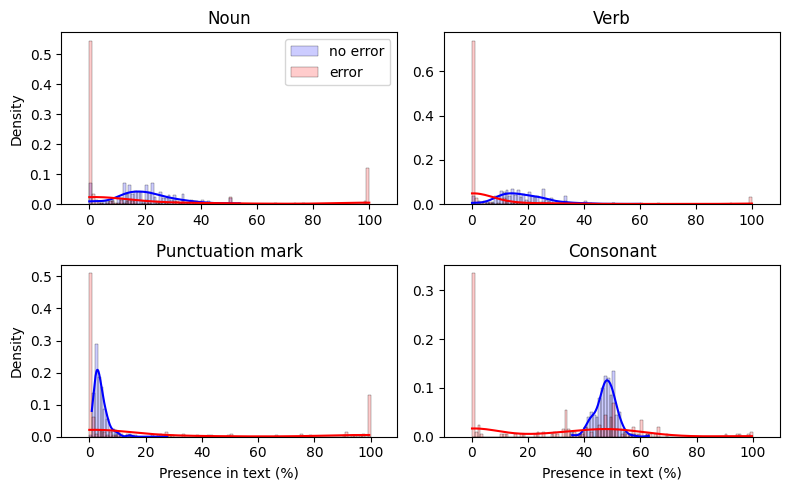

In [36]:
### Examining the training dataset
dfProcessed_opus = pd.read_excel('./backup_df_saved/dfProcessed_opus_test_fp16_1.xlsx')
dfProcessed_opus_test = pd.read_excel('./backup_df_saved/dfProcessed_opus_test_fp16_1.xlsx')

dfProcessed_opus_error = dfProcessed_opus[dfProcessed_opus['error'] == 1]
dfProcessed_opus_no_error = dfProcessed_opus[dfProcessed_opus['error'] == 0]

features_analysis = ['NOUN', 'VERB', 'punctuation_mark', 'consonant']
features_name = ['Noun', 'Verb', 'Punctuation mark', 'Consonant']

n = len(features_analysis) // 2 + len(features_analysis) % 2

fig, axes = plt.subplots(2, n, figsize=(8, 5))

for i, feature in enumerate(features_analysis):
    row = i // n
    col = i % n
    
    sns.histplot(dfProcessed_opus_no_error[feature] * 100, binrange=(0, 100), bins=100, kde=True, alpha=0.2, label='no error', stat='density', ax=axes[row, col], color='blue')
    sns.histplot(dfProcessed_opus_error[feature] * 100, binrange=(0, 100), bins=100, kde=True, alpha=0.2, label='error', stat='density', ax=axes[row, col], color='red')
    
    size_1 = (dfProcessed_opus_no_error[feature].max() - dfProcessed_opus_no_error[feature].min()) * 100
    size_2 = (dfProcessed_opus_error[feature].max() - dfProcessed_opus_error[feature].min()) * 100
    
    final_size = max(size_1, size_2)
    extends = final_size * 0.1
    
    min_x = min(dfProcessed_opus_no_error[feature].min(), dfProcessed_opus_error[feature].min()) * 100 - extends
    max_x = max(dfProcessed_opus_no_error[feature].max(), dfProcessed_opus_error[feature].max()) * 100 + extends
    axes[row, col].set_xlim(min_x, max_x)
    axes[row, col].set_title(f'{features_name[i]}')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('')
    if col == 0:
        axes[row, col].set_ylabel('Density')
    if row == 1:
        axes[row, col].set_xlabel('Presence in text (%)')
    
    if i == 0:
        axes[row, col].legend()
    
    for line in axes[row, col].get_lines():
        line.set_alpha(1)

# Elimina el eje vacío si el número de características es impar
if len(features_analysis) % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.savefig('./figs/features_opus.png', dpi=900)
plt.show()

### Training
#### Splitting train validation dataset

In [37]:
X_opus = dfProcessed_opus
y_opus = dfProcessed_opus['error']

In [38]:
X_opus_train, X_opus_validation, y_opus_train, y_opus_validation = train_test_split(X_opus, y_opus, test_size=0.2, random_state=random_state)


#### Training the final model and validation

accuracy:  0.9375
recall:  0.9343180389692017


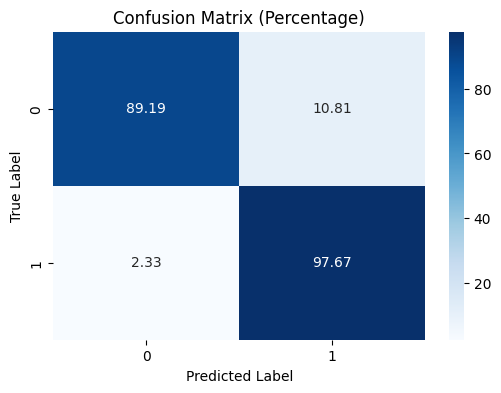

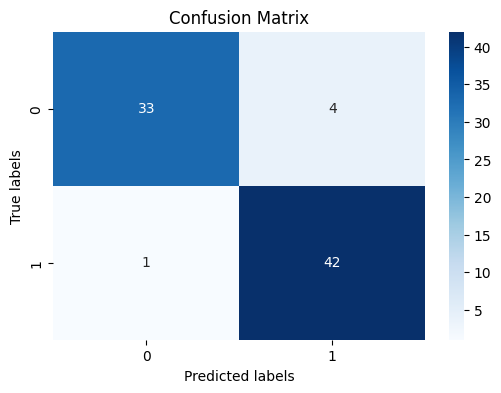

memory: None
steps: [('scaler', StandardScaler()), ('clf', RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                       n_estimators=50, random_state=66))]
verbose: False
scaler: StandardScaler()
clf: RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                       n_estimators=50, random_state=66)
scaler__copy: True
scaler__with_mean: True
scaler__with_std: True
clf__bootstrap: True
clf__ccp_alpha: 0.0
clf__class_weight: None
clf__criterion: gini
clf__max_depth: 10
clf__max_features: sqrt
clf__max_leaf_nodes: None
clf__max_samples: None
clf__min_impurity_decrease: 0.0
clf__min_samples_leaf: 2
clf__min_samples_split: 10
clf__min_weight_fraction_leaf: 0.0
clf__n_estimators: 50
clf__n_jobs: None
clf__oob_score: False
clf__random_state: 66
clf__verbose: 0
clf__warm_start: False


In [39]:
model_opus = RandomForestClassifier(random_state=random_state, bootstrap=True, criterion='gini', max_depth=10,
                               max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease= 0.0 , 
                               min_samples_leaf= 2, min_samples_split= 10, min_weight_fraction_leaf= 0.0, 
                               n_estimators= 50)

pipeline_opus = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model_opus)])


feats_elected_opus = ['punctuation_mark', 'digit', 'ADP', 'words_density', 'NUM', 'VERB', 'blank', 'DET', 'vowel', 'PRON', 'NOUN', 'PRT', 'uppercase_middle', 'ADV', 'four_or_more_consonants', 'three_or_more_digits_or_letters_equal']



X_opus_train_subset = X_opus_train[feats_elected_opus]
X_opus_validation_subset = X_opus_validation[feats_elected_opus]

pipeline_opus.fit(X_opus_train_subset, y_opus_train)


predictions = pipeline_opus.predict(X_opus_validation_subset)


validation_accuracy = accuracy_score(y_opus_validation, predictions)
validation_recall = recall_score(y_opus_validation, predictions, average='macro')
print('accuracy: ', validation_accuracy)
print('recall: ', validation_recall)

conf_matrix_test = confusion_matrix(y_opus_validation, predictions)


row_totals = conf_matrix_test.sum(axis=1)
conf_matrix_percentage = conf_matrix_test / row_totals[:, np.newaxis] * 100 


plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Percentage)')
plt.show()     

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

false_negatives_idx = (predictions == 0) & (y_opus_validation == 1)

false_negatives = X_opus_validation[false_negatives_idx]

hyperparameters = pipeline_opus.get_params()

for param, value in hyperparameters.items():
    print(f'{param}: {value}')

### Testing the model

accuracy:  0.9625
recall:  0.9624999999999999


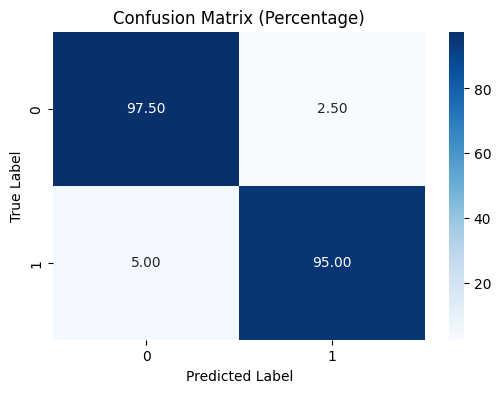

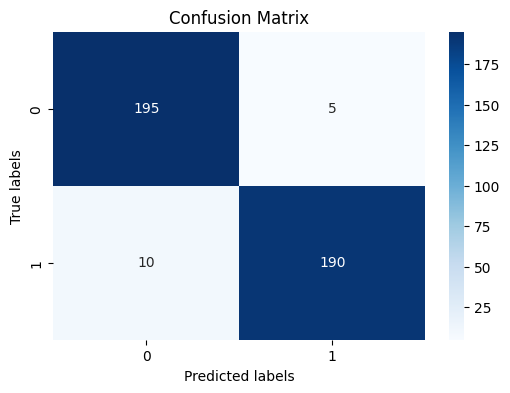

In [40]:
X_opus_test = dfProcessed_opus_test[feats_elected_opus]
y_opus_test = dfProcessed_opus_test['error']

pipeline_validation_opus = pipeline_opus 

predicted_probabilities_test_opus = pipeline_validation_opus.predict_proba(X_opus_test)[:, 1] 

threshold_opus = 0.5
predictions_test_opus = (predicted_probabilities_test_opus > threshold_opus).astype(int)
#predictions_test_opus = pipeline_validation_opus.predict(X_opus_test)
conf_matrix_test = confusion_matrix(y_opus_test, predictions_test_opus)
validation_accuracy = accuracy_score(y_opus_test, predictions_test_opus)
validation_recall = recall_score(y_opus_test, predictions_test_opus, average='macro')
print('accuracy: ', validation_accuracy)
print('recall: ', validation_recall)

row_totals = conf_matrix_test.sum(axis=1)
conf_matrix_percentage = conf_matrix_test / row_totals[:, np.newaxis] * 100  
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Percentage)')
plt.show()      
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()
false_negatives_test_idx = (predictions_test_opus == 0) & (y_opus_test == 1)
false_positives_test_idx = (predictions_test_opus == 1) & (y_opus_test == 0)
true_positive_test_idx =  (predictions_test_opus == 1) & (y_opus_test == 1)
true_negatives_test_idx = (predictions_test_opus == 0) & (y_opus_test == 0)
false_negatives_test = dfProcessed_opus_test[false_negatives_test_idx]
#false_negatives_test.to_excel('./false_negatives_test_opus.xlsx', index=False)
false_positives_test = dfProcessed_opus_test[false_positives_test_idx]
#false_positives_test.to_excel('./false_positives_test_opus.xlsx', index=False)

true_positives_test = dfProcessed_opus_test[true_positive_test_idx]
true_negatives_test = dfProcessed_opus_test[true_negatives_test_idx]


#### Feature importances

/var/folders/pd/pxf5dh257zx9_fxppr8kt8yc0000gn/T/ipykernel_40857/1511160153.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_opus[sorted_indices_opus], y=np.array(feature_names_opus)[sorted_indices_opus], palette='viridis')
/Users/javier/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/javier/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning

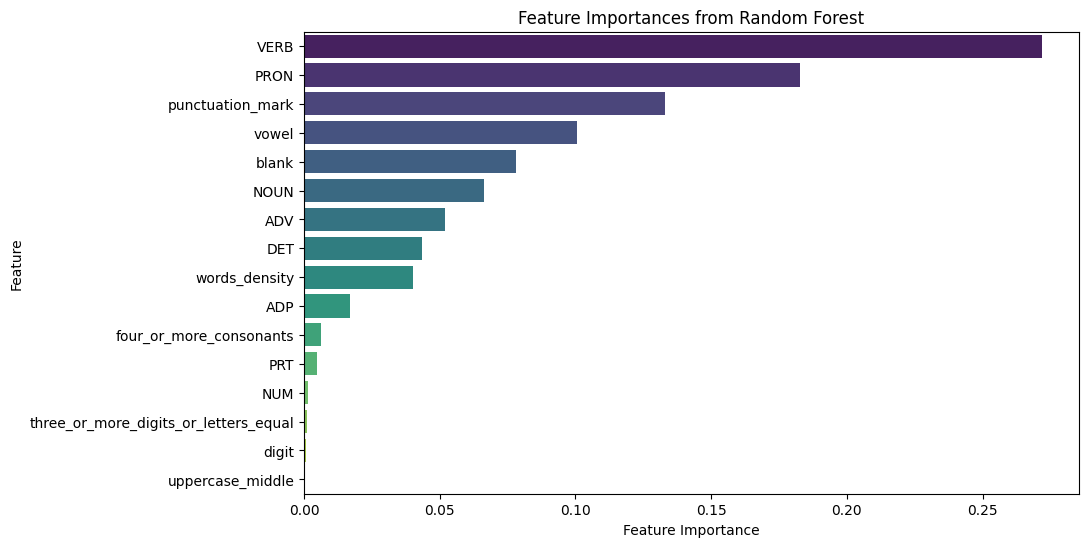

In [41]:
# Feature importance
feature_importances_opus = model_opus.feature_importances_
feature_names_opus = feats_elected_opus

# Sort features by importance
sorted_indices_opus = np.argsort(feature_importances_opus)[::-1]

print()

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_opus[sorted_indices_opus], y=np.array(feature_names_opus)[sorted_indices_opus], palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.show()

In [42]:
importances_opus = model_opus.feature_importances_

importance_df_opus = pd.DataFrame({'Feature': X_opus_train_subset.columns, 'Importance': importances_opus})
importance_df_opus = importance_df_opus.sort_values(by='Importance', ascending=False)

print(importance_df_opus)
print(importance_df_opus['Feature'].values)

                                  Feature  Importance
5                                    VERB    0.271913
9                                    PRON    0.182717
0                        punctuation_mark    0.132825
8                                   vowel    0.100538
6                                   blank    0.078210
10                                   NOUN    0.066400
13                                    ADV    0.052089
7                                     DET    0.043352
3                           words_density    0.040285
2                                     ADP    0.017022
14                four_or_more_consonants    0.006275
11                                    PRT    0.004952
4                                     NUM    0.001369
15  three_or_more_digits_or_letters_equal    0.001076
1                                   digit    0.000695
12                       uppercase_middle    0.000283
['VERB' 'PRON' 'punctuation_mark' 'vowel' 'blank' 'NOUN' 'ADV' 'DET'
 'words_densi

saving the model

In [43]:
dump(pipeline_validation_opus, './models/pipeline_opus_model_FP16.joblib')

['./models/pipeline_opus_model_FP16.joblib']